In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tvDatafeed import TvDatafeed, Interval



<Axes: xlabel='Date'>

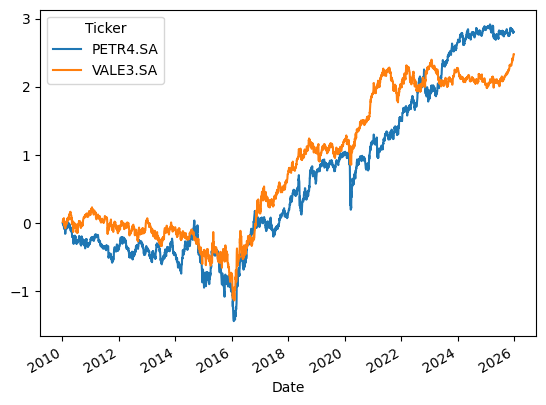

In [4]:
# =========================
# PARÂMETROS
# =========================
ticker = ['VALE3.SA','PETR4.SA'] # código do ativo no yahoo
start_date = "2010-01-01"
end_date = None

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=True,
    back_adjust=True,
    multi_level_index=False,
    
)['Close'].dropna()
df_rets = df.pct_change()
df_rets.dropna(inplace=True)
df_rets.cumsum().plot()


In [5]:
# Opções de resample:
# 'D'    - diário (calendar days)
# 'B'    - dias úteis (business days)
# 'W-FRI' - semanal com fechamento na sexta-feira
# 'M'    - fim do mês (month end)
# 'MS'   - início do mês (month start)
# 'ME'   - fim do mês (équivalente a 'M' / MonthEnd)
# 'QE' / 'Q-DEC' - fim de trimestre (padrão dezembro)
# 'A' / 'A-DEC' - fim de ano (padrão dezembro)
# Exemplos de uso: df.resample('M').last(), df.resample('W-FRI').sum(), df.resample('A-DEC').mean()
monthly_prices = df.resample("2ME").last()
monthly_ret = monthly_prices.pct_change().dropna()


monthly_ret_lag = monthly_ret.shift(1).dropna()


selected_asset = monthly_ret_lag.idxmin(axis=1)

positions = pd.DataFrame(
    0,
    index=monthly_prices.index,
    columns=df.columns
)

for date, asset in selected_asset.items():
    if pd.notna(asset):
        positions.loc[date, asset] = 1
        
df_positions = positions.reindex(df.index,method="ffill").dropna()
stratgey_ret = (df_rets * df_positions).sum(axis=1)
df_rets['strategy'] = stratgey_ret
df_rets.dropna(inplace=True)
df_ret_acum = df_rets.cumsum()
df_ret_acum.tail()

Ticker,PETR4.SA,VALE3.SA,strategy
Date,,,
2025-12-17,2.799626,2.438829,5.579514
2025-12-18,2.793834,2.441394,5.573722
2025-12-19,2.797394,2.448501,5.577282
2025-12-22,2.800296,2.477718,5.580185
2025-12-23,2.805377,2.477443,5.585265


In [6]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3], 
    vertical_spacing=0.05
)

fig.add_trace(
    go.Scatter(
        x=df_ret_acum.index,
        y=df_ret_acum[ticker[0]] * 100,
        name=f"{ticker[0]}",
        line=dict(width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_ret_acum.index,
        y=df_ret_acum[ticker[1]] * 100,
        name=f"{ticker[1]}",
        line=dict(width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_ret_acum.index,
        y=df_ret_acum["strategy"] * 100,
        name="Strategy",
        line=dict(width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_positions.index,
        y=df_positions[ticker[0]],
        name=f"Alocado {ticker[0]}",
        line=dict(width=2),
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_positions.index,
        y=df_positions[ticker[1]],
        name=f"Alocado {ticker[1]}",
        line=dict(width=2),
    ),
    row=2, col=1
)

fig.update_layout(
    title=f"{ticker} | last period loser",
    template="plotly_white",
    height=700,
    legend=dict(x=0.01, y=0.99)
)

fig.update_yaxes(
    title_text="Cumulative Return (%)",
    row=1, col=1
)

fig.update_yaxes(
    title_text="Position",
    range=[-0.05, 1.05],
    row=2, col=1
)

fig.update_xaxes(title_text="Date", row=2, col=1)

fig.show()




In [7]:
total_return_t0 = df_ret_acum[ticker[0]].iloc[-1]
total_return_t1 = df_ret_acum[ticker[1]].iloc[-1]
total_return_strategy = df_ret_acum["strategy"].iloc[-1]

vol_t0 = df_rets[ticker[0]].std() * np.sqrt(252)
vol_t1 = df_rets[ticker[1]].std() * np.sqrt(252)
vol_strategy = df_rets["strategy"].std() * np.sqrt(252)

sharpe_t0 = (df_rets[ticker[0]].mean() / df_rets[ticker[0]].std()) * np.sqrt(252)
sharpe_t1 = (df_rets[ticker[1]].mean() / df_rets[ticker[1]].std()) * np.sqrt(252)
sharpe_strategy = (df_rets["strategy"].mean() / df_rets["strategy"].std()) * np.sqrt(252)

print("=== RESULTADOS ===")
print(f"{ticker[0]} Return: {total_return_t0:.2%}")
print(f"{ticker[1]} Return: {total_return_t1:.2%}")
print(f"Strategy Return: {total_return_strategy:.2%}")
print()
print(f"{ticker[0]} Vol: {vol_t0:.2%}")
print(f"{ticker[1]} Vol: {vol_t1:.2%}")
print(f"Strategy Vol: {vol_strategy:.2%}")
print()
print(f"{ticker[0]} Sharpe: {sharpe_t0:.2f}")
print(f"{ticker[1]} Sharpe: {sharpe_t1:.2f}")
print(f"Strategy Sharpe: {sharpe_strategy:.2f}")


=== RESULTADOS ===
VALE3.SA Return: 247.74%
PETR4.SA Return: 280.54%
Strategy Return: 558.53%

VALE3.SA Vol: 38.85%
PETR4.SA Vol: 43.24%
Strategy Vol: 39.79%

VALE3.SA Sharpe: 0.40
PETR4.SA Sharpe: 0.41
Strategy Sharpe: 0.89
